<a href="https://colab.research.google.com/github/Jeelanihansha/Working-with-NumPy-Matrices-and-Multidimensional-Data/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Introduction***

In this project, I analyzed NHANES body measurement data for adult male and female participants. The aim was to compare their weight distribution, compute descriptive statistics, and derive additional health-related measures such as BMI and waist ratios.



***Task 1–2: Data Loading***

In this section, I loaded the male and female CSV files into NumPy arrays and checked their shapes. I also removed rows containing missing values to ensure that the analysis and visualizations were accurate.

---



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
male = np.genfromtxt('nhanes_adult_male_bmx_2020.csv', delimiter=',', skip_header=1)
female = np.genfromtxt('nhanes_adult_female_bmx_2020.csv', delimiter=',', skip_header=1)
print("Male shape:", male.shape, "Female shape:", female.shape)

Male shape: (4082, 7) Female shape: (4222, 7)


***Task 3: Weight Histograms***

In this section, I plotted histograms of female and male weights using the same x-axis limits. This allowed me to compare the weight distributions directly and observe the general difference between the two groups.

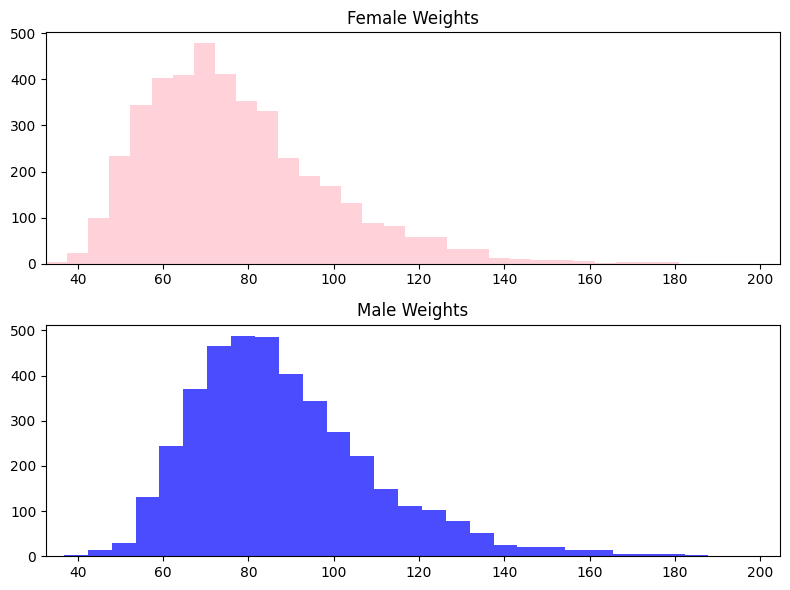

In [ ]:
male_weights = male[:, 0]
female_weights = female[:, 0]

# Filter out NaN values from the weight arrays
male_weights_filtered = male_weights[~np.isnan(male_weights)]
female_weights_filtered = female_weights[~np.isnan(female_weights)]

min_w = min(male_weights_filtered.min(), female_weights_filtered.min())
max_w = max(male_weights_filtered.max(), female_weights_filtered.max())

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))
ax1.hist(female_weights_filtered, bins=30, alpha=0.7, color='pink') # Use filtered data for plotting
ax1.set_title('Female Weights')
ax1.set_xlim(min_w, max_w)
ax2.hist(male_weights_filtered, bins=30, alpha=0.7, color='blue') # Use filtered data for plotting
ax2.set_title('Male Weights')
ax2.set_xlim(min_w, max_w)
plt.tight_layout()
plt.show()

***Task 4: Weight Boxplot***

In this section, I created a box-and-whisker plot to compare male and female weights side by side. This plot helped me identify the median, spread, and outliers in both distributions.

**Task 5: Weight Aggregates**

In this section, I computed the mean, median, standard deviation, minimum, and maximum for both male and female weights. These descriptive statistics helped me summarize and compare the two groups numerically.

/tmp/ipykernel_21931/1613156098.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([female_weights, male_weights], labels=['Female', 'Male'])


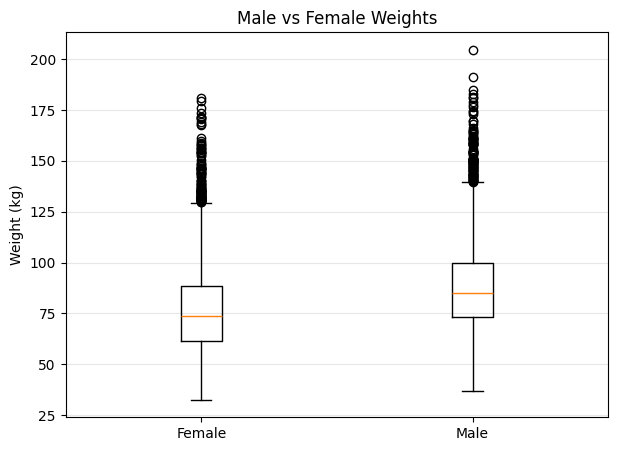

Female mean: 77.40379057095475
Female median: 73.6
Female std: 21.54250829019315
Female min: 32.6
Female max: 180.9
Male mean: 88.36454300416565
Male median: 85.0
Male std: 21.418936717962495
Male min: 36.8
Male max: 204.6


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Remove rows with NaN values first
male = male[~np.isnan(male).any(axis=1)]
female = female[~np.isnan(female).any(axis=1)]
# Extract weight columns
female_weights = female[:, 0]
male_weights = male[:, 0]
# Task 4: Boxplot
plt.figure(figsize=(7, 5))
plt.boxplot([female_weights, male_weights], labels=['Female', 'Male'])
plt.ylabel('Weight (kg)')
plt.title('Male vs Female Weights')
plt.grid(axis='y', alpha=0.3)
plt.show()
# Task 5: Aggregates
print("Female mean:", np.mean(female_weights))
print("Female median:", np.median(female_weights))
print("Female std:", np.std(female_weights))
print("Female min:", np.min(female_weights))
print("Female max:", np.max(female_weights))

print("Male mean:", np.mean(male_weights))
print("Male median:", np.median(male_weights))
print("Male std:", np.std(male_weights))
print("Male min:", np.min(male_weights))
print("Male max:", np.max(male_weights))

***Task 6: BMI Calculation***

In this section, I added a BMI column to the female dataset by using the standard formula based on weight and height. This allowed me to include BMI as an additional body measurement for later analysis.

***Task 7: Standardization***

In this section, I standardized all female measurements using z-scores. This transformation made the variables comparable on the same scale and prepared the data for correlation analysis.

In [ ]:
# Task 6: Add BMI to female (weight / (height_m)^2)
female_bmi = female[:, 0] / ((female[:, 1] / 100) ** 2)
female = np.column_stack((female, female_bmi))  # Now 8 cols

# Task 7: Standardize female (z-scores)
zfemale = (female - np.mean(female, axis=0)) / np.std(female, axis=0)
print("zfemale shape:", zfemale.shape)

zfemale shape: (4221, 8)


***Task 8: Correlation Analysis***

In this section, I created a scatterplot matrix for selected standardized variables and calculated Pearson and Spearman correlation coefficients. This helped me examine the relationships between height, weight, waist circumference, hip circumference, and BMI.

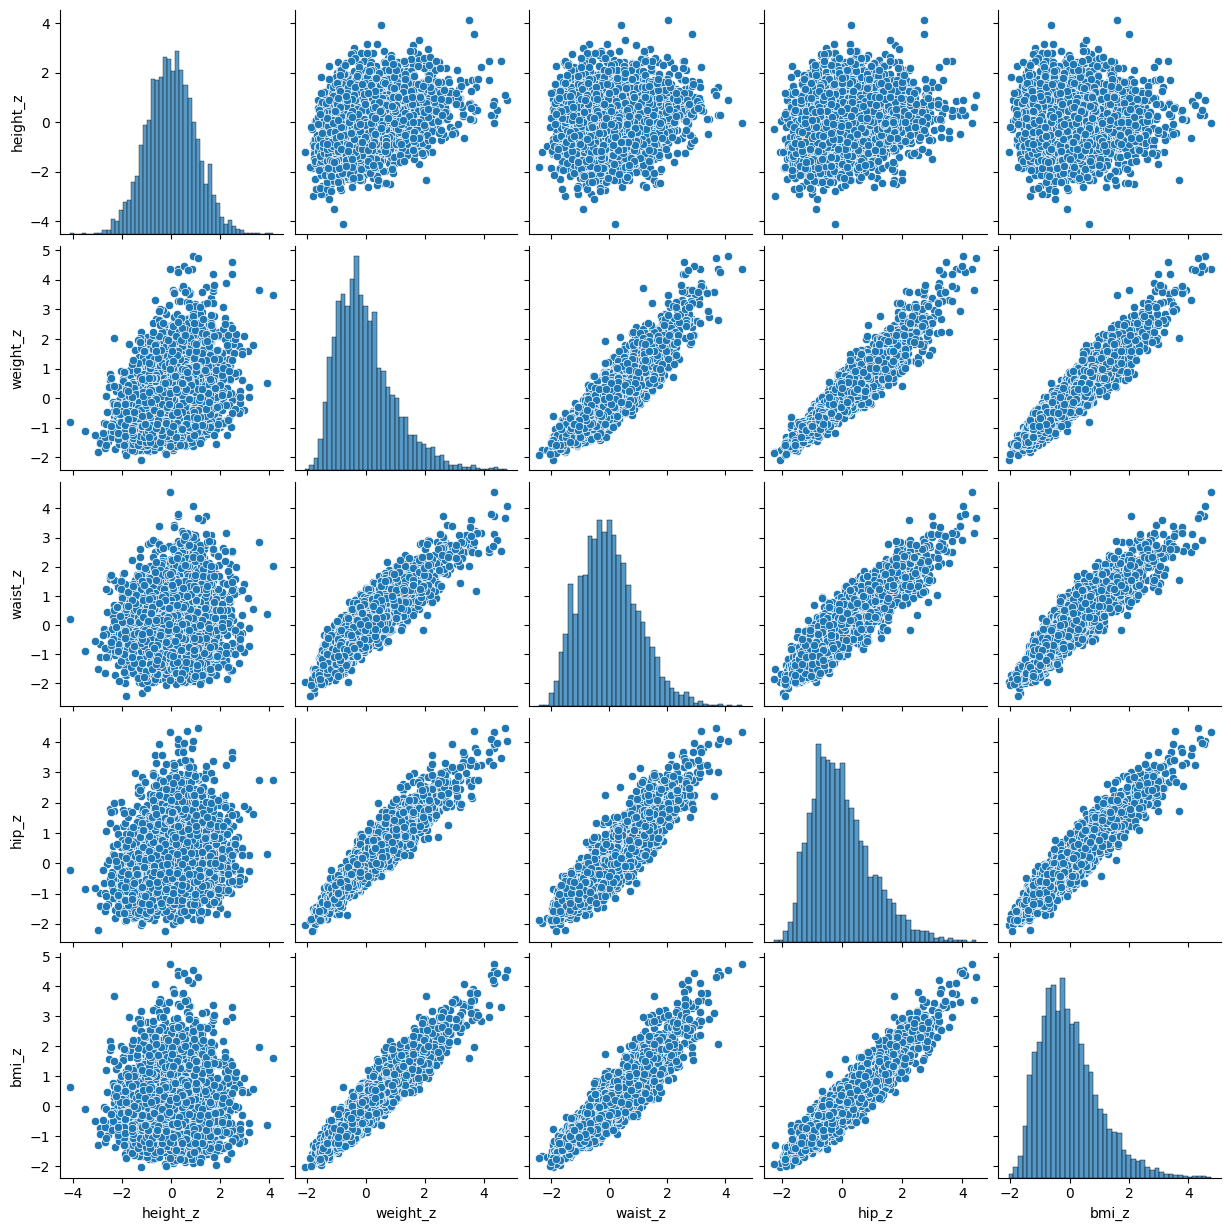

height vs weight: Pearson=0.345, Spearman=0.339
height vs waist: Pearson=0.127, Spearman=0.109
height vs hip: Pearson=0.203, Spearman=0.205
height vs bmi: Pearson=0.033, Spearman=0.020
weight vs waist: Pearson=0.905, Spearman=0.900
weight vs hip: Pearson=0.947, Spearman=0.947
weight vs bmi: Pearson=0.946, Spearman=0.938
waist vs hip: Pearson=0.897, Spearman=0.888
waist vs bmi: Pearson=0.921, Spearman=0.923
hip vs bmi: Pearson=0.944, Spearman=0.934


In [ ]:
from scipy.stats import pearsonr, spearmanr
import pandas as pd
zf_cols = zfemale[:, [1, 0, 6, 5, 7]]
zf_df = pd.DataFrame(zf_cols, columns=['height_z', 'weight_z', 'waist_z', 'hip_z', 'bmi_z'])
import seaborn as sns
sns.pairplot(zf_df)
plt.show()
# Correlations
vars = ['height', 'weight', 'waist', 'hip', 'bmi']
for i in range(5):
    for j in range(i+1, 5):
        pear = pearsonr(zf_cols[:, i], zf_cols[:, j])[0]
        spe = spearmanr(zf_cols[:, i], zf_cols[:, j])[0]
        print(f"{vars[i]} vs {vars[j]}: Pearson={pear:.3f}, Spearman={spe:.3f}")

***Task 9: Waist Ratios***

In this section, I computed the waist-to-height ratio and waist-to-hip ratio for both male and female participants. These measures provided additional insight into body fat distribution and health risk.

***Task 10: Waist Ratio Boxplot***

In this section, I plotted boxplots for the waist-to-height and waist-to-hip ratios of both sexes. This allowed me to compare the distribution and variation of these ratios visually.

/tmp/ipykernel_21931/1582002985.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(ratios, labels=labels)


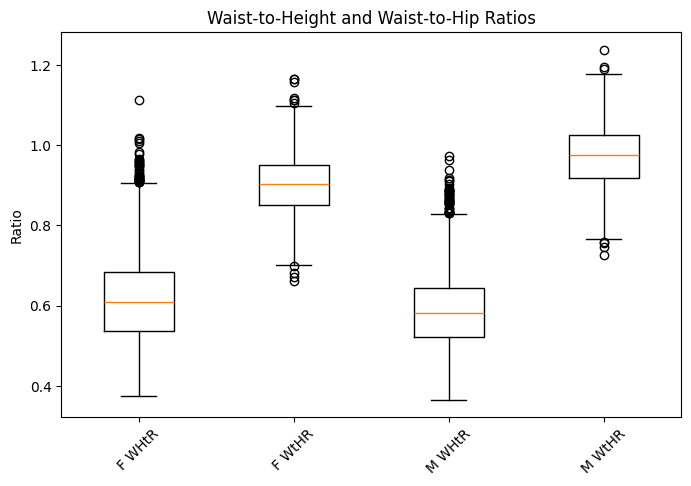

In [ ]:
# Task 9: Add ratios (waist/height, waist/hip) to both
male_whr = male[:, 6] / male[:, 1]  # waist-to-height
male_wtr = male[:, 6] / male[:, 5]  # waist-to-hip
male = np.column_stack((male, male_whr, male_wtr))

female_whr = female[:, 6] / female[:, 1]
female_wtr = female[:, 6] / female[:, 5]
female = np.column_stack((female, female_whr, female_wtr))

# Task 10: Boxplot
ratios = [female_whr, female_wtr, male_whr, male_wtr]
labels = ['F WHtR', 'F WtHR', 'M WHtR', 'M WtHR']
plt.figure(figsize=(8, 5))
plt.boxplot(ratios, labels=labels)
plt.ylabel('Ratio')
plt.title('Waist-to-Height and Waist-to-Hip Ratios')
plt.xticks(rotation=45)
plt.show()

**Task 11: The advantages and disadvantages of BMI, waist-to-height ratio, and waist-to-hip ratio.**


BMI is easy to calculate and useful for quick screening because it uses only height and weight. It is widely used in reports and studies because it gives a quick idea of whether a person may be underweight, normal weight, overweight, or obese.

BMI has the disadvantage that it does not distinguish between muscle and fat, and it does not show where fat is stored in the body. Because of this, it may give misleading results for muscular people or people with very different body shapes.

Waist-to-height ratio is a simple measure that helps identify central obesity and is often considered better than BMI for showing abdominal fat risk. It is also easy to understand and compare across different people because it relates waist size to body height.

Waist-to-height ratio has the disadvantage that it does not directly measure body fat and depends on accurate waist and height measurements. It gives only a general indication of risk, so it cannot fully describe a person’s body composition.

Waist-to-hip ratio is useful because it shows how fat is distributed around the abdomen and hips, which can help assess health risk. It is especially helpful when studying central obesity and fat pattern distribution.

Waist-to-hip ratio has the disadvantage that it does not measure total body fat and can be influenced by body shape, muscle structure, and measurement errors. It can also be harder to interpret than BMI for a general audience..



**Task 12: Lowest and Highest BMI**


In this section, I selected the five participants with the lowest BMI and the five with the highest BMI using sorting. I then printed their standardized measurements to compare body characteristics at the extremes of the BMI distribution.

In [ ]:
# Sort by BMI (col 7), get indices for lowest/highest 5
bmi_idx = np.argsort(female[:, 7])
low5 = zfemale[bmi_idx[:5], :]
high5 = zfemale[bmi_idx[-5:], :]

print("Lowest 5 BMI (standardized):")
print(low5)
print("\nHighest 5 BMI (standardized):")
print(high5)

Lowest 5 BMI (standardized):
[[-2.07978523 -1.22299143 -1.5478402  -1.16905675 -2.1947611  -2.0405496
  -1.94212128 -2.05024028]
 [-1.88017988 -0.18929313 -1.71835247  0.38637892 -2.4443617  -1.85491922
  -2.05708015 -1.99487987]
 [-1.53667299  1.80730222  0.62619127  0.5730312  -2.26607556 -1.6756899
  -1.7064556  -1.97088383]
 [-1.843044   -0.26009438 -0.22637009  0.51081377 -2.30173278 -2.25178417
  -1.85590213 -1.94177591]
 [-1.61094475  0.88688592 -0.09848588  0.47970506 -2.21258971 -1.82931504
  -1.71220354 -1.89319577]]

Highest 5 BMI (standardized):
[[ 4.2472403   0.29215539  1.86240524 -0.98240447  2.3693641   4.10445598
   3.81731803  4.39649161]
 [ 4.45612963  0.50455915  1.69189297 -1.13794804  3.34993787  3.98283607
   2.90339503  4.46201122]
 [ 4.34936397  0.27799514  2.84285081  1.94181459  4.36616887  3.9188256
   3.75409065  4.51466896]
 [ 4.8042785   0.88688592  2.11817365  1.81737973  3.77782461  4.02124236
   4.08172343  4.54270932]
 [ 4.36328993 -0.03353037 -0.0558

**References**

CDC. NHANES Survey Methods and Analytic Guidelines.

CDC. NHANES Anthropometry Procedures Manual 2021.

CDC. Body Measures Data Documentation (BMX).

NHANES public data source used in this project.

